# Exploratory Data Analysis

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [4]:
# DC Metro Lines data
metro = gpd.read_file("data/dc_metro_lines_regional.geojson")

# Access Across America data
access = gpd.read_file("data/dc_2014_access_across_america_shapefiles/47900_tr_2014_0700-0859.shp")

In [11]:
# understand data
print('Metro lines:')
print(metro["NAME"].unique())
print('\nJob counts:')
print(access["tot_jobs"].describe())

Metro lines:
<StringArray>
['red', 'yellow', 'green', 'orange', 'silver', 'blue']
Length: 6, dtype: str

Job counts:
count     87574.000000
mean      29662.821933
std       92150.343739
min          -1.000000
25%         134.000000
50%        2183.500000
75%       12892.750000
max      798240.000000
Name: tot_jobs, dtype: float64


In [3]:
# inspect CRS and columns of both datasets
print("Metro CRS:", metro.crs)
print("Access CRS:", access.crs)
print("Metro columns:", metro.columns.tolist())
print("Access columns:", access.columns.tolist())
print(access.head())

Metro CRS: EPSG:4326
Access CRS: EPSG:4326
Metro columns: ['NAME', 'WEB_URL', 'GIS_ID', 'OBJECTID', 'SE_ANNO_CAD_DATA', 'CREATED', 'EDITED', 'GLOBALID', 'SHAPELEN', 'geometry']
Access columns: ['geoid', 'threshold', 'tot_jobs', 'geometry']
             geoid  threshold  tot_jobs  \
0  110010001001000         30    301018   
1  110010001001001         30    317294   
2  110010001001002         30    387903   
3  110010001001003         30    374947   
4  110010001001004         30    394093   

                                            geometry  
0  POLYGON ((-77.06689 38.91866, -77.06647 38.918...  
1  POLYGON ((-77.06427 38.91465, -77.06422 38.914...  
2  POLYGON ((-77.06093 38.91191, -77.06093 38.911...  
3  POLYGON ((-77.0593 38.91253, -77.0593 38.91246...  
4  POLYGON ((-77.06238 38.91148, -77.0623 38.9112...  


In [12]:
# convert crs to web mercator (contextily basemaps use Web Mercator EPSG:3857)
metro = metro.to_crs(epsg=3857)
access = access.to_crs(epsg=3857)

In [13]:
# Crop map to the area around the Metro lines
minx, miny, maxx, maxy = metro.total_bounds
pad = 5000  # meters of padding
access = access.cx[minx - pad:maxx + pad, miny - pad:maxy + pad]

# Split silver line from other lines
SILVER_NAME = "silver"
silver = metro[metro["NAME"].str.lower() == SILVER_NAME]
others = metro[metro["NAME"].str.lower() != SILVER_NAME]

c:\Users\pkmu004\Documents\transit-buildout-analysis\.venv\Lib\site-packages\contextily\tile.py:298: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tile_urls = [provider.build_url(x=tile.x, y=tile.y, z=tile.z) for tile in tiles]


SSLError: HTTPSConnectionPool(host='a.basemaps.cartocdn.com', port=443): Max retries exceeded with url: /light_all/10/291/390.png (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1082)')))

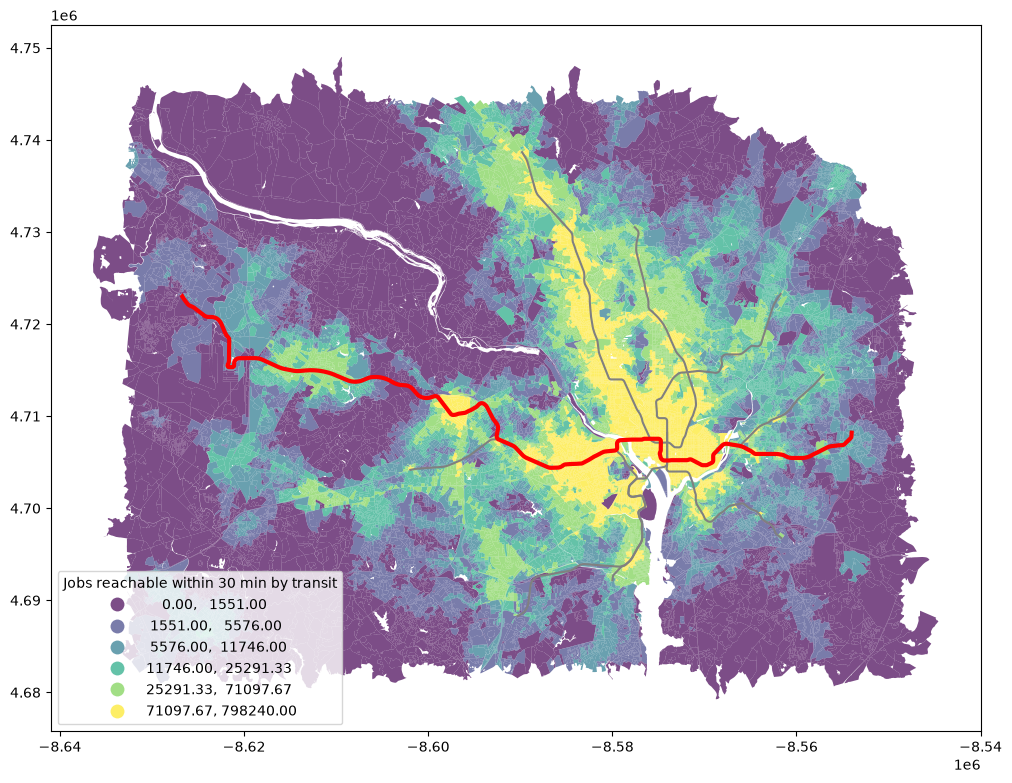

In [15]:
# Plotting
fig, ax = plt.subplots(figsize=(12, 12))

access.plot(
    column="tot_jobs",
    cmap="viridis",
    scheme="quantiles",
    k=6,
    legend=True,
    legend_kwds={"title": "Jobs reachable within 30 min by transit", "loc": "lower left"},
    alpha=0.7,
    linewidth=0,
    ax=ax,
)

others.plot(ax=ax, color="gray", linewidth=1.5)
silver.plot(ax=ax, color="red", linewidth=3)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

# Lock the extent so the basemap doesn't add white margins around the map
ax.set_extent([minx - pad, maxx + pad, miny - pad, maxy + pad])

# Remove axis frame, ticks, and labels
ax.set_axis_off()
for spine in ax.spines.values():
    spine.set_visible(False)

# Title and subtitle
fig.suptitle("Washington D.C. job accessibility by transit in 2014", fontsize=16, fontweight="bold", y=0.98)
ax.set_title("Silver line highlighted in red", fontsize=12, color="dimgray", pad=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("dc_metro_access_map.png", dpi=200, bbox_inches="tight")
plt.show()